In [1]:
# Initialize Otter
import otter
grader = otter.Notebook("hw8.ipynb")

# CPSC 330 - Applied Machine Learning

## Homework 8: Introduction to Computer vision, Time Series, and Survival Analysis (Lectures 19 to 20) 

**Due date: see the [Apr 07, 11:59 pm](https://github.com/UBC-CS/cpsc330-2024W2?tab=readme-ov-file#deliverable-due-dates-tentative).**

## Imports

In [2]:
from hashlib import sha1

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder, OneHotEncoder

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score

<div class="alert alert-info">
    
## Submission instructions
<hr>
rubric={points:2}

Follow the [homework submission instructions](https://github.com/UBC-CS/cpsc330-2024W2/blob/main/docs/homework_instructions.md). 

**You may work in a group on this homework and submit your assignment as a group.** Below are some instructions on working as a group.  
- The maximum group size is 2. 
- Use group work as an opportunity to collaborate and learn new things from each other. 
- Be respectful to each other and make sure you understand all the concepts in the assignment well. 
- It's your responsibility to make sure that the assignment is submitted by one of the group members before the deadline. 
- You can find the instructions on how to do group submission on Gradescope [here](https://help.gradescope.com/article/m5qz2xsnjy-student-add-group-members).


When you are ready to submit your assignment do the following:

1. Run all cells in your notebook to make sure there are no errors by doing `Kernel -> Restart Kernel and Clear All Outputs` and then `Run -> Run All Cells`. 
2. Notebooks with cell execution numbers out of order will have marks deducted. Notebooks without the output displayed may not be graded at all (because we need to see the output in order to grade your work).
3. Upload the assignment using Gradescope's drag and drop tool. Check out this [Gradescope Student Guide](https://lthub.ubc.ca/guides/gradescope-student-guide/) if you need help with Gradescope submission.
4. Make sure that the plots and output are rendered properly in your submitted file. 
5. If the .ipynb file is too big and doesn't render on Gradescope, also upload a pdf or html in addition to the .ipynb.

<br><br>

## Exercise 1: time series prediction

In this exercise we'll be looking at a [dataset of avocado prices](https://www.kaggle.com/neuromusic/avocado-prices). You should start by downloading the dataset and storing it under the `data` folder. We will be forcasting average avocado price for the next week. 

In [3]:
df = pd.read_csv("data/avocado.csv", parse_dates=["Date"], index_col=0)
df.head()

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,1.33,64236.62,1036.74,54454.85,48.16,8696.87,8603.62,93.25,0.0,conventional,2015,Albany
1,2015-12-20,1.35,54876.98,674.28,44638.81,58.33,9505.56,9408.07,97.49,0.0,conventional,2015,Albany
2,2015-12-13,0.93,118220.22,794.70,109149.67,130.50,8145.35,8042.21,103.14,0.0,conventional,2015,Albany
3,2015-12-06,1.08,78992.15,1132.00,71976.41,72.58,5811.16,5677.40,133.76,0.0,conventional,2015,Albany
4,2015-11-29,1.28,51039.60,941.48,43838.39,75.78,6183.95,5986.26,197.69,0.0,conventional,2015,Albany


In [4]:
df.shape

(18249, 13)

In [5]:
df["Date"].min()

Timestamp('2015-01-04 00:00:00')

In [6]:
df["Date"].max()

Timestamp('2018-03-25 00:00:00')

It looks like the data ranges from the start of 2015 to March 2018 (~2 years ago), for a total of 3.25 years or so. Let's split the data so that we have a 6 months of test data.

In [7]:
split_date = '20170925'
df_train = df[df["Date"] <= split_date]
df_test  = df[df["Date"] >  split_date]

In [8]:
assert len(df_train) + len(df_test) == len(df)

<br><br>

<!-- BEGIN QUESTION -->

### 1.1 How many time series? 
rubric={points:4}

In the [Rain in Australia](https://www.kaggle.com/datasets/jsphyg/weather-dataset-rattle-package) dataset from lecture demo, we had different measurements for each Location. 

We want you to consider this for the avocado prices dataset. For which categorical feature(s), if any, do we have separate measurements? Justify your answer by referencing the dataset.

<div class="alert alert-warning">

Solution_1.1
    
</div>

_Points:_ 4

We could have seperate time series measurements per region. Could also have seperate measurements per type of avocado.

In [9]:
print("Num unique regions:", df['region'].nunique())
print(df['region'].unique())

Num unique regions: 54
['Albany' 'Atlanta' 'BaltimoreWashington' 'Boise' 'Boston'
 'BuffaloRochester' 'California' 'Charlotte' 'Chicago' 'CincinnatiDayton'
 'Columbus' 'DallasFtWorth' 'Denver' 'Detroit' 'GrandRapids' 'GreatLakes'
 'HarrisburgScranton' 'HartfordSpringfield' 'Houston' 'Indianapolis'
 'Jacksonville' 'LasVegas' 'LosAngeles' 'Louisville' 'MiamiFtLauderdale'
 'Midsouth' 'Nashville' 'NewOrleansMobile' 'NewYork' 'Northeast'
 'NorthernNewEngland' 'Orlando' 'Philadelphia' 'PhoenixTucson'
 'Pittsburgh' 'Plains' 'Portland' 'RaleighGreensboro' 'RichmondNorfolk'
 'Roanoke' 'Sacramento' 'SanDiego' 'SanFrancisco' 'Seattle'
 'SouthCarolina' 'SouthCentral' 'Southeast' 'Spokane' 'StLouis' 'Syracuse'
 'Tampa' 'TotalUS' 'West' 'WestTexNewMexico']


In [10]:
df.groupby(['region', 'type'])['Date'].nunique()

region               type        
Albany               conventional    169
                     organic         169
Atlanta              conventional    169
                     organic         169
BaltimoreWashington  conventional    169
                                    ... 
TotalUS              organic         169
West                 conventional    169
                     organic         169
WestTexNewMexico     conventional    169
                     organic         166
Name: Date, Length: 108, dtype: int64

Plotting the following graph without specifying the type shows a lot of data spaced 0 days apart indiciating duplicates. It apppears that every week a data sample was taken from each region for each type of avocado.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.2 Equally spaced measurements? 
rubric={points:4}

In the Rain in Australia dataset, the measurements were generally equally spaced but with some exceptions. How about with this dataset? Justify your answer by referencing the dataset.

<div class="alert alert-warning">

Solution_1.2
    
</div>

_Points:_ 4

_Type your answer here, replacing this text._

In [11]:
def plot_time_spacing_distribution(df, region, type):  #from class notes
    df['Date'] = pd.to_datetime(df['Date'])
    data = df[(df['region'] == region) & (df['type']==type)]
    
    if data.empty:
        print(f"No data available for region: {region}")
        return

    time_diffs = data['Date'].sort_values().diff().dropna()
    

    value_counts = time_diffs.value_counts().sort_index()

    print(f"Time spacing counts for {region}:\n{value_counts}\n")
    
    # Plot the bar chart
    plt.bar(value_counts.index.astype(str), value_counts.values, color='skyblue', edgecolor='black')
    plt.title(f"Time Difference Distribution for {region} and type {type}")
    plt.xlabel("Time Difference (days)")
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.show()

Time spacing counts for NewYork:
Date
7 days    168
Name: count, dtype: int64



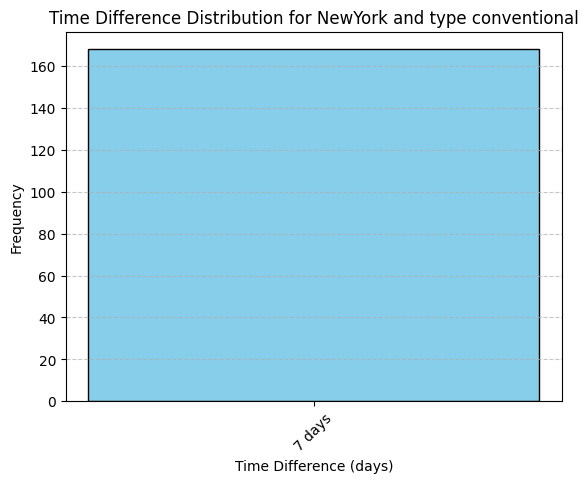

In [12]:
plot_time_spacing_distribution(df, region='NewYork', type='conventional')

In [13]:
region_type_pairs = df[['region', 'type']].drop_duplicates()

irregular_pairs = []

# Loop through each pair
for i, row in region_type_pairs.iterrows():
    region = row['region']
    type = row['type']
    
    data = df[(df['region'] == region) & (df['type'] == type)]
    time_diffs = data['Date'].sort_values().diff().dropna()
    value_counts = time_diffs.value_counts().sort_index()

    if any(value_counts.index != pd.Timedelta(days=7)):
        irregular_pairs.append((region, type))
        print(f"Irregular: {region} {type}")
        print(value_counts, "\n")


Irregular: WestTexNewMexico organic
Date
7 days     163
14 days      1
21 days      1
Name: count, dtype: int64 



Time spacing counts for WestTexNewMexico:
Date
7 days     163
14 days      1
21 days      1
Name: count, dtype: int64



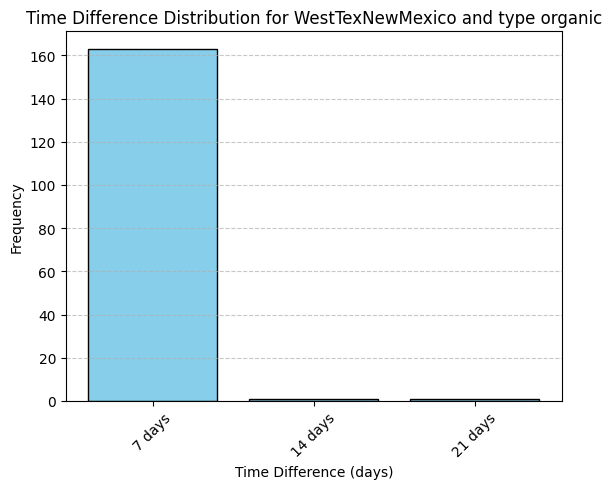

In [14]:
plot_time_spacing_distribution(df, region='WestTexNewMexico', type='organic')

Time spacing counts for WestTexNewMexico:
Date
7 days    168
Name: count, dtype: int64



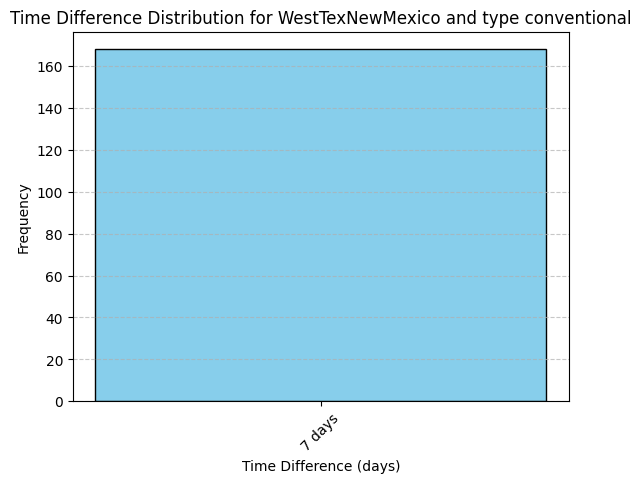

In [15]:
plot_time_spacing_distribution(df, region='WestTexNewMexico', type='conventional')

It appears all the time series are equally spaced except for WestTexNewMexico Organic type.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.3 Interpreting regions 
rubric={points:4}

In the Rain in Australia dataset, each location was a different place in Australia. For this dataset, look at the names of the regions. Do you think the regions are also all distinct, or are there overlapping regions? Justify your answer by referencing the data.

<div class="alert alert-warning">

Solution_1.3
    
</div>

_Points:_ 4

I'm not very familiar with American geography but right off the bat I suspect that TotalUS overlaps with every other region in the dataset. Midsouth also sounds like it could incorporate multiple cities? countires? same as the entirety of California. Also like what is "West" or "Plains" they also sound like they coudl have lots of overlap. 

In [16]:
print(df['region'].unique())

['Albany' 'Atlanta' 'BaltimoreWashington' 'Boise' 'Boston'
 'BuffaloRochester' 'California' 'Charlotte' 'Chicago' 'CincinnatiDayton'
 'Columbus' 'DallasFtWorth' 'Denver' 'Detroit' 'GrandRapids' 'GreatLakes'
 'HarrisburgScranton' 'HartfordSpringfield' 'Houston' 'Indianapolis'
 'Jacksonville' 'LasVegas' 'LosAngeles' 'Louisville' 'MiamiFtLauderdale'
 'Midsouth' 'Nashville' 'NewOrleansMobile' 'NewYork' 'Northeast'
 'NorthernNewEngland' 'Orlando' 'Philadelphia' 'PhoenixTucson'
 'Pittsburgh' 'Plains' 'Portland' 'RaleighGreensboro' 'RichmondNorfolk'
 'Roanoke' 'Sacramento' 'SanDiego' 'SanFrancisco' 'Seattle'
 'SouthCarolina' 'SouthCentral' 'Southeast' 'Spokane' 'StLouis' 'Syracuse'
 'Tampa' 'TotalUS' 'West' 'WestTexNewMexico']


In [17]:
data_TotalUS = df[(df['region'] == 'TotalUS') & (df['type'] == 'conventional')]
data_Atlanta = df[(df['region'] == 'Atlanta') & (df['type'] == 'conventional')]

data_TotalUS

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-12-27,0.95,27297983.67,9626901.09,10197890.05,1184340.09,6288852.44,4850404.09,1252626.31,185822.04,conventional,2015,TotalUS
1,2015-12-20,0.98,25083647.17,8710021.76,9329861.85,1201020.01,5842743.55,4618389.66,1025048.77,199305.12,conventional,2015,TotalUS
2,2015-12-13,0.93,28041335.38,9855053.66,10805838.91,1016163.17,6364279.64,4964462.13,1371440.28,28377.23,conventional,2015,TotalUS
3,2015-12-06,0.89,28800396.57,9405464.36,12160838.62,931830.63,6302262.96,5005077.36,1233956.21,63229.39,conventional,2015,TotalUS
4,2015-11-29,0.99,22617999.38,8094803.56,9003178.41,731008.41,4789009.00,3901953.04,856560.34,30495.62,conventional,2015,TotalUS
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7,2018-02-04,0.87,62505646.52,21620180.90,20445501.03,1066830.22,19373134.37,13384586.80,5719096.61,269450.96,conventional,2018,TotalUS
8,2018-01-28,1.09,40171640.84,14551799.50,12119884.61,575974.74,12923981.99,9749412.19,3041125.42,133444.38,conventional,2018,TotalUS
9,2018-01-21,1.08,42939821.55,14218843.83,13929702.12,928815.12,13862460.48,9866218.28,3789722.90,206519.30,conventional,2018,TotalUS
10,2018-01-14,1.20,37299945.22,12600918.24,11866197.84,652808.40,12180020.74,8128241.88,3917569.95,134208.91,conventional,2018,TotalUS


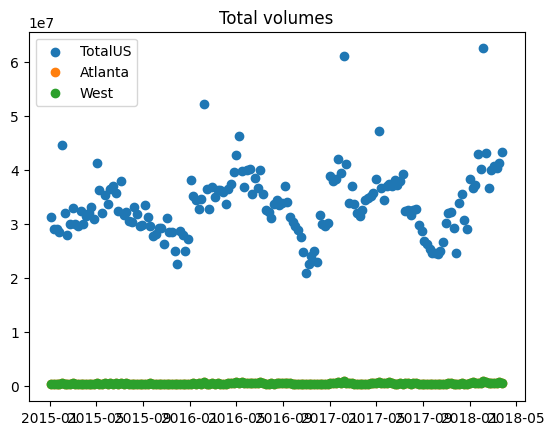

In [18]:
plt.scatter(data_TotalUS['Date'], data_TotalUS['Total Volume'], label='TotalUS')
plt.scatter(data_Atlanta['Date'], data_Atlanta['Total Volume'], label="Atlanta")
plt.scatter(data_Atlanta['Date'], data_Atlanta['Total Volume'], label="West")
plt.legend()
plt.title('Total volumes')
plt.show()

<!-- END QUESTION -->

<br><br>

C:\Users\ellay\AppData\Local\Temp\ipykernel_22376\2975810623.py:9: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


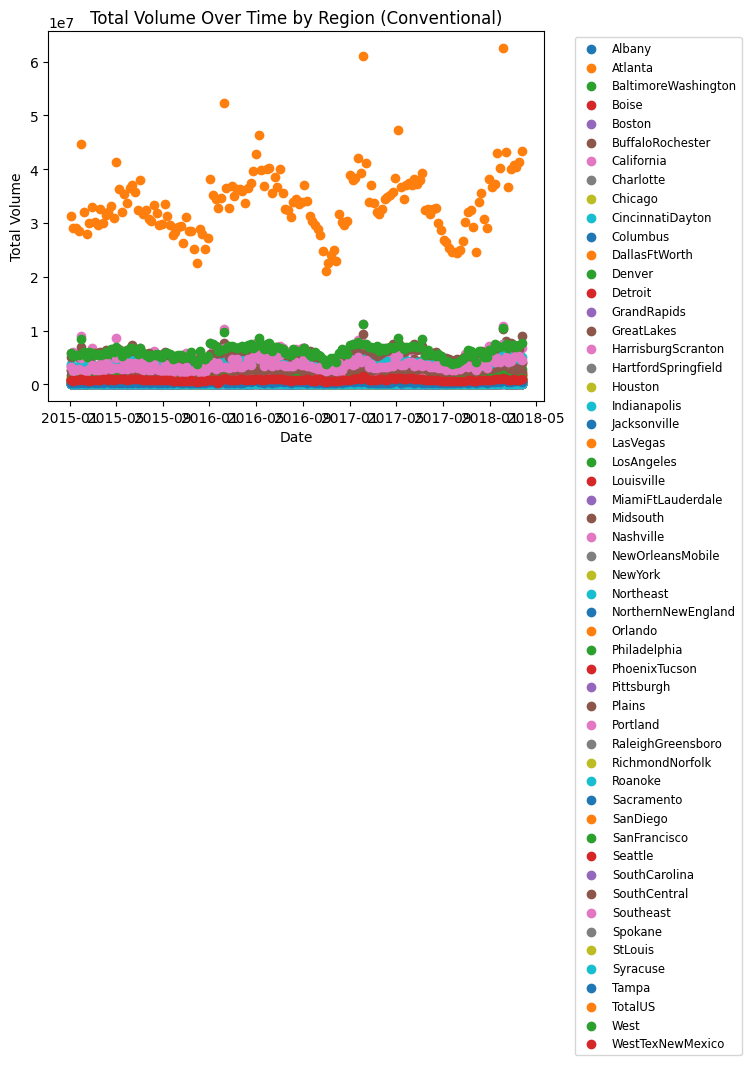

In [19]:

for region in df['region'].unique():
    region_data = df[(df['region'] == region) & (df['type'] == 'conventional')]
    plt.scatter(region_data['Date'], region_data['Total Volume'], label=region)  

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.xlabel("Date")
plt.ylabel("Total Volume")
plt.title("Total Volume Over Time by Region (Conventional)")
plt.tight_layout()
plt.show()


Thats a lot of places.... But it seems apparent that TotalUS is an aggregate of the data from all the regions in the US.

We will use the entire dataset despite any location-based weirdness uncovered in the previous part.

We will be trying to forecast the avocado price. The function below is adapted from [Lecture 19](https://github.com/UBC-CS/cpsc330-2024W2/tree/main/lectures), with some improvements.

In [20]:
def create_lag_feature(df, orig_feature, lag, groupby, new_feature_name=None, clip=False):
    """
    Creates a new feature that's a lagged version of an existing one.
    
    NOTE: assumes df is already sorted by the time columns and has unique indices.
    
    Parameters
    ----------
    df : pandas.core.frame.DataFrame
        The dataset.
    orig_feature : str
        The column name of the feature we're copying
    lag : int
        The lag; negative lag means values from the past, positive lag means values from the future
    groupby : list
        Column(s) to group by in case df contains multiple time series
    new_feature_name : str
        Override the default name of the newly created column
    clip : bool
        If True, remove rows with a NaN values for the new feature
    
    Returns
    -------
    pandas.core.frame.DataFrame
        A new dataframe with the additional column added.
        
    """
        
    if new_feature_name is None:
        if lag < 0:
            new_feature_name = "%s_lag%d" % (orig_feature, -lag)
        else:
            new_feature_name = "%s_ahead%d" % (orig_feature, lag)
    
    new_df = df.assign(**{new_feature_name : np.nan})
    for name, group in new_df.groupby(groupby):        
        if lag < 0: # take values from the past
            new_df.loc[group.index[-lag:],new_feature_name] = group.iloc[:lag][orig_feature].values
        else:       # take values from the future
            new_df.loc[group.index[:-lag], new_feature_name] = group.iloc[lag:][orig_feature].values
            
    if clip:
        new_df = new_df.dropna(subset=[new_feature_name])
        
    return new_df

We first sort our dataframe properly:

In [21]:
df_sort = df.sort_values(by=["region", "type", "Date"]).reset_index(drop=True)
df_sort

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany
...,...,...,...,...,...,...,...,...,...,...,...,...,...
18244,2018-02-25,1.57,18421.24,1974.26,2482.65,0.00,13964.33,13698.27,266.06,0.0,organic,2018,WestTexNewMexico
18245,2018-03-04,1.54,17393.30,1832.24,1905.57,0.00,13655.49,13401.93,253.56,0.0,organic,2018,WestTexNewMexico
18246,2018-03-11,1.56,22128.42,2162.67,3194.25,8.93,16762.57,16510.32,252.25,0.0,organic,2018,WestTexNewMexico
18247,2018-03-18,1.56,15896.38,2055.35,1499.55,0.00,12341.48,12114.81,226.67,0.0,organic,2018,WestTexNewMexico


We then call `create_lag_feature`. This creates a new column in the dataset `AveragePriceNextWeek`, which is the following week's `AveragePrice`. We have set `clip=True` which means it will remove rows where the target would be missing.

In [22]:
df_hastarget = create_lag_feature(df_sort, "AveragePrice", +1, ["region", "type"], "AveragePriceNextWeek", clip=True)
df_hastarget

,Date,AveragePrice,Total Volume,4046,4225,4770,Total Bags,Small Bags,Large Bags,XLarge Bags,type,year,region,AveragePriceNextWeek
0,2015-01-04,1.22,40873.28,2819.50,28287.42,49.90,9716.46,9186.93,529.53,0.0,conventional,2015,Albany,1.24
1,2015-01-11,1.24,41195.08,1002.85,31640.34,127.12,8424.77,8036.04,388.73,0.0,conventional,2015,Albany,1.17
2,2015-01-18,1.17,44511.28,914.14,31540.32,135.77,11921.05,11651.09,269.96,0.0,conventional,2015,Albany,1.06
3,2015-01-25,1.06,45147.50,941.38,33196.16,164.14,10845.82,10103.35,742.47,0.0,conventional,2015,Albany,0.99
4,2015-02-01,0.99,70873.60,1353.90,60017.20,179.32,9323.18,9170.82,152.36,0.0,conventional,2015,Albany,0.99
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18243,2018-02-18,1.56,17597.12,1892.05,1928.36,0.00,13776.71,13553.53,223.18,0.0,organic,2018,WestTexNewMexico,1.57
18244,2018-02-25,1.57,18421.24,1974.26,2482.65,0.00,13964.33,13698.27,266.06,0.0,organic,2018,WestTexNewMexico,1.54
18245,2018-03-04,1.54,17393.30,1832.24,1905.57,0.00,13655.49,13401.93,253.56,0.0,organic,2018,WestTexNewMexico,1.56
18246,2018-03-11,1.56,22128.42,2162.67,3194.25,8.93,16762.57,16510.32,252.25,0.0,organic,2018,WestTexNewMexico,1.56


Our goal is to predict `AveragePriceNextWeek`. 

Let's split the data:

In [23]:
df_train = df_hastarget[df_hastarget["Date"] <= split_date]
df_test  = df_hastarget[df_hastarget["Date"] >  split_date]

<br><br>

<!-- BEGIN QUESTION -->

### 1.4 `AveragePrice` baseline 
rubric={points}

Soon we will want to build some models to forecast the average avocado price a week in advance. Before we start with any ML though, let's try a baseline. Previously we used `DummyClassifier` or `DummyRegressor` as a baseline. This time, we'll do something else as a baseline: we'll assume the price stays the same from this week to next week. So, we'll set our prediction of "AveragePriceNextWeek" exactly equal to "AveragePrice", assuming no change. That is kind of like saying, "If it's raining today then I'm guessing it will be raining tomorrow". This simplistic approach will not get a great score but it's a good starting point for reference. If our model does worse that this, it must not be very good. 

Using this baseline approach, what $R^2$ do you get on the train and test data?

<div class="alert alert-warning">

Solution_1.4
    
</div>

_Points:_ 4

_Type your answer here, replacing this text._

In [24]:
from sklearn.metrics import r2_score
df_train.loc[:, "BaselinePredictions"] = df_train["AveragePrice"]
df_test.loc[:, "BaselinePredictions"] = df_test["AveragePrice"]

C:\Users\ellay\AppData\Local\Temp\ipykernel_22376\925762068.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train.loc[:, "BaselinePredictions"] = df_train["AveragePrice"]
C:\Users\ellay\AppData\Local\Temp\ipykernel_22376\925762068.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_test.loc[:, "BaselinePredictions"] = df_test["AveragePrice"]


In [25]:
train_r2 = r2_score(df_train["AveragePriceNextWeek"], df_train["BaselinePredictions"])
print(f"Train R2: {train_r2}")

Train R2: 0.8285800937261841


In [26]:
test_r2 = r2_score(df_test["AveragePriceNextWeek"], df_test["BaselinePredictions"])
print(f"Test R2: {test_r2}")

Test R2: 0.7631780188583048


In [27]:
assert not train_r2 is None, "Are you using the correct variable name?"
assert not test_r2 is None, "Are you using the correct variable name?"
assert sha1(str(round(train_r2, 3)).encode('utf8')).hexdigest() == 'b1136fe2a8918904393ab6f40bfb3f38eac5fc39', "Your training score is not correct. Are you using the right features?"
assert sha1(str(round(test_r2, 3)).encode('utf8')).hexdigest() == 'cc24d9a9b567b491a56b42f7adc582f2eefa5907', "Your test score is not correct. Are you using the right features?"

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 1.5 Forecasting average avocado price
rubric={points:10}

Now that the baseline is done, let's build some models to forecast the average avocado price a week later. Experiment with a few approachs for encoding the date. Justify the decisions you make. Which approach worked best? Report your test score and briefly discuss your results.

Benchmark: you should be able to achieve $R^2$ of at least 0.79 on the test set. I got to 0.80, but not beyond that. Let me know if you do better!

Note: because we only have 2 splits here, we need to be a bit wary of overfitting on the test set. Try not to test on it a ridiculous number of times. If you are interested in some proper ways of dealing with this, see for example sklearn's [TimeSeriesSplit](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.TimeSeriesSplit.html), which is like cross-validation for time series data.

<div class="alert alert-warning">

Solution_1.5
    
</div>

_Points:_ 10

Lets split the dates into month day and year to allow us (and the model) to interpret them betta
Lets also add a last week price to the features to give the model some more context

In [28]:
#make model more interpretable imo
df_train["dayofweek"] = df_train["Date"].dt.dayofweek
df_train["month"] = df_train["Date"].dt.month
df_train["year"] = df_train["Date"].dt.year
df_train = create_lag_feature(df_train, "AveragePrice", -1, ["region", "type"], "AveragePriceLastWeek", clip=True)
df_train = create_lag_feature(df_train, "AveragePrice", -2, ["region", "type"], "AveragePriceLastLastWeek", clip=True)


df_test["dayofweek"] = df_test["Date"].dt.dayofweek
df_test["month"] = df_test["Date"].dt.month
df_test["year"] = df_test["Date"].dt.year
df_test = create_lag_feature(df_test, "AveragePrice", -1, ["region", "type"], "AveragePriceLastWeek", clip=True)
df_test = create_lag_feature(df_test, "AveragePrice", -2, ["region", "type"], "AveragePriceLastLastWeek", clip=True)

C:\Users\ellay\AppData\Local\Temp\ipykernel_22376\1523591178.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["dayofweek"] = df_train["Date"].dt.dayofweek
C:\Users\ellay\AppData\Local\Temp\ipykernel_22376\1523591178.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train["month"] = df_train["Date"].dt.month
C:\Users\ellay\AppData\Local\Temp\ipykernel_22376\1523591178.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score, TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import RandomForestRegressor

In [30]:
features = ["AveragePrice", "Total Volume", "month", "dayofweek", "year"]  
target = "AveragePriceNextWeek"

#splitta da data
X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

lr = LinearRegression()
lr.fit(X_train, y_train)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores= cross_val_score(lr, X_train, y_train, cv=tscv, scoring='r2')
print(f"CV scores without last week data: {cv_scores}")
print(f"Mean CV score without last week data: {np.mean(cv_scores)}")

CV scores without last week data: [0.79413373 0.80302227 0.86872466 0.8401522  0.81658394]
Mean CV score without last week data: 0.8245233577650801


Try Linear Regression

In [31]:

features = ["AveragePrice", "Total Volume", "month", "dayofweek", "year", "AveragePriceLastWeek"]  
target = "AveragePriceNextWeek"

#splitta da data
X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

lr = LinearRegression()
lr.fit(X_train, y_train)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores= cross_val_score(lr, X_train, y_train, cv=tscv, scoring='r2')
print(f"CV scores with last week data: {cv_scores}")
print(f"Mean CV score with last week data: {np.mean(cv_scores)}")


CV scores with last week data: [0.8109171  0.81365974 0.88411678 0.853029   0.83503018]
Mean CV score with last week data: 0.8393505569370256


In [32]:

features = ["AveragePrice", "Total Volume", "month", "dayofweek", "year", "AveragePriceLastWeek", "AveragePriceLastLastWeek"]  
target = "AveragePriceNextWeek"

#splitta da data
X_train = df_train[features]
y_train = df_train[target]
X_test = df_test[features]
y_test = df_test[target]

lr = LinearRegression()
lr.fit(X_train, y_train)

tscv = TimeSeriesSplit(n_splits=5)
cv_scores= cross_val_score(lr, X_train, y_train, cv=tscv, scoring='r2')
print(f"CV scores with last and last last week data: {cv_scores}")
print(f"Mean CV score with last and last last  week data: {np.mean(cv_scores)}")



CV scores with last and last last week data: [0.81616738 0.81428914 0.88486824 0.85788771 0.84406413]
Mean CV score with last and last last  week data: 0.8434553201544045


I won't increase the number of past weeks any further because I dont wanna pass too many parameters to the model as itll be less interpretable. It'd probably be better but I just want a model thats easy to understand rn.

In [33]:
preds_lr = lr.predict(X_test)
print("Linear Regression R²:", r2_score(y_test, preds_lr))

Linear Regression R²: 0.7519760471745618


Lets try a random forest

In [34]:
rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, None],
    'min_samples_split': [2, 5]
}

tscv = TimeSeriesSplit(n_splits=5)

grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=tscv,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best params:", grid_search.best_params_)
print("Best CV R2:", grid_search.best_score_)



Fitting 5 folds for each of 8 candidates, totalling 40 fits
Best params: {'max_depth': 5, 'min_samples_split': 5, 'n_estimators': 50}
Best CV R2: 0.8386288827998571


In [35]:
best_rf = grid_search.best_estimator_
preds = best_rf.predict(X_test)

print("Test R²:", r2_score(y_test, preds))


Test R²: 0.7656173449286809


Slightly beetter than the linear regression. Could probably optimizer further with more hyper param tuning but my computer aint doing that fast enough.

<!-- END QUESTION -->

<br><br><br><br>

## Exercise 2: Short answer questions

<!-- BEGIN QUESTION -->

### 2.1 Time series

rubric={points:6}

The following questions pertain to Lecture 20 on time series data:

1. Sometimes a time series has missing time points or, worse, time points that are unequally spaced in general. Give an example of a real world situation where the time series data would have unequally spaced time points.
2. In class we discussed two approaches to using temporal information: encoding the date as one or more features, and creating lagged versions of features. Which of these (one/other/both/neither) two approaches would struggle with unequally spaced time points? Briefly justify your answer.
3. When studying time series modeling, we explored several ways to encode date information as a feature for the citibike dataset. When we used time of day as a numeric feature, the Ridge model was not able to capture the periodic pattern. Why? How did we tackle this problem? Briefly explain.

<div class="alert alert-warning">

Solution_2.1
    
</div>

_Points:_ 6

1) Some emergency events like tsunamis, hurricanes, earthquakes would not happen periodically. Well I guess you could always set count to 0 every day there isn't one lol. Maybe events like credit card transactions or security cameras detecting a person (could just set count to 0 every time there is no person though...)

2) If you do not have a constitent time gap between datapoints then lagging the data by "1" each time wouldn't really work because "1" wouldn't have a consistent value. It could represent differnt gaps in time if you don't somehow normalize the time differences between events. Day of week can still be encoded as day of week whether you collected data every Wednesday, or sporadically.

3) Time is cyclic. If you don't do some magic to make the model treat it as cyclic, then it won't understand that 11pm (23:00) is closer to 1am (1:00) than it is to 8PM (20:000). In the lecture notes we turned time of day into a categorical feature.


<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

### 2.2 Computer vision 
rubric={points:6}

The following questions pertain to Lecture 19 on multiclass classification and introduction to computer vision. 

1. How many parameters (coefficients and intercepts) will `sklearn`’s `LogisticRegression()` model learn for a four-class classification problem, assuming that you have 10 features? Briefly explain your answer.
2. In Lecture 19, we briefly discussed how neural networks are sort of like `sklearn`'s pipelines, in the sense that they involve multiple sequential transformations of the data, finally resulting in the prediction. Why was this property useful when it came to transfer learning?
3. Imagine that you have a small dataset with ~1000 images containing pictures and names of 50 different Computer Science faculty members from UBC. Your goal is to develop a reasonably accurate multi-class classification model for this task. Describe which model/technique you would use and briefly justify your choice in one to three sentences.

<div class="alert alert-warning">

Solution_2.2
    
</div>

_Points:_ 6

1) If it needs to predict four classes and we have 10 features then we'll have 10 coefficients per class so 40 coefficients. We will also learn 4 intercepts (one per class). This results in 44 params to learn.

2) With transfer learning, we can steal someone else's nicely trained model and only retrain the final few layers to fine tune it to our new task. This saves us time, computing power, and data. We can use the early parts of their "pipeline" and then fine tune it to our purposes"

3) I think its fun to train things from scratch, but maybe that would not be accurate or would be too time consuming haha. You can use someone elses pretrained CNN that was already designed to recognzie faces, but then use transfer learning to fine tune the model to recognize the CS faculty members faces.

<!-- END QUESTION -->

<br><br>

<!-- BEGIN QUESTION -->

## 2.3 Survival analysis
<hr>

rubric={points:6}

The following questions pertain to Lecture 21 on survival analysis. We'll consider the use case of customer churn analysis.

1. What is the problem with simply labeling customers are "churned" or "not churned" and using standard supervised learning techniques?
2. Consider customer A who just joined last week vs. customer B who has been with the service for a year. Who do you expect will leave the service first: probably customer A, probably customer B, or we don't have enough information to answer? Briefly explain your answer. 
3. If a customer's survival function is almost flat during a certain period, how do we interpret that?

<div class="alert alert-warning">

Solution_2.3
    
</div>

_Points:_ 6

1) It could be that a customer has not had adequate time to churn. They would be labeled "not churned" but that doesn't necessarily mean they are unlikely to churn. Take someone who has been a customer for 50 years and not churned vs someone who joined 20 min ago but did not churn. They are both labeled not churned but its much more likely that the customer of 50 years will not churn because they have a history of not churning.

2) If a customer has been with us for a long time, it's more likely they like us and will stay. A wont necessarily leave though, but they are less proven to stay.

3) The probability of them stayins is not changing. They probably won't change from not churned to churned. 

<!-- END QUESTION -->

<br><br>

**Before submitting your assignment, please make sure you have followed all the instructions in the Submission instructions section at the top.** 

![](img/eva-well-done.png)